# Create a notebook environment

## From PowerShell

```pwsh
# Create and enter a new Python virtual environment for the notebook
mkdir pynotebook
cd pynotebook
python -m venv --upgrade-deps .venv
.\.venv\Scripts\activate.ps1

# Install the notebook dependencies
pip install jupyter seaborn
```

# Open the notebook in VS Code

1. Install the Python notebook extension for VS Code named [**Jupyter**](https://marketplace.visualstudio.com/items?itemName=ms-toolsai.jupyter)
   * View raw data with [**Data Wrangler**](https://marketplace.visualstudio.com/items?itemName=ms-toolsai.datawrangler)
   * Render diagrams with [**Markdown Preview Mermaid**](https://marketplace.visualstudio.com/items?itemName=bierner.markdown-mermaid)
1. Copy this file to the `pynotebook` folder
1. Copy the csv files to a subfolder named `data`
1. Open the `pynotebook` folder in VS Code and open this file
1. Select the new Python `.venv` as the **Jupyter kernel** for this file
   * More details in the VS Code [**tutorial for data science**](https://code.visualstudio.com/docs/datascience/jupyter-notebooks#_create-or-open-a-jupyter-notebook)

# Measurement setup

## Electrical connections

1. Connect a **variable power supply** _(Vref)_ to the QT Py S3
   * 🟥 Positive terminal to every analog input channel _(AIx)_
   * ⬛ Negative terminal to the ground pin _(Ground)_
1. Measure the power supply voltage with a **DMM**
1. Set the voltage to a reference value
1. Collect voltage measurements from the QT Py S3 analog channels

See [**characterization_setup.md**](./characterization_setup.md) for a diagram.

## Measurement pseudo-code

1. Take `N` samples from each channel and average them
1. Sweep `N` across a decade-spaced series
1. Repeat the test `K` times
1. Add a data entry containing
   * an identifier for QT Py S3
   * the analog input channel
   * the number of samples averaged
   * the resulting ADC code

```py
test_runs = 30
samples_to_average_list = [1, 10, 20, 50, 100, 200, 500, 1000, 2000]

for _ in range(test_runs):
    for samples_to_average in samples_to_average_list:
        for analog_input in sorted(analog_input_channels):
            average_channel_code = take_n(analog_input, samples_to_average)
```


# Begin the notebook

In [113]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import seaborn.objects as so

import IPython.display as idisplay
import matplotlib.ticker

readable_format = matplotlib.ticker.EngFormatter()

def display_markdown(markdown_string):
    idisplay.display_markdown(markdown_string, raw=True)

# Load the data files

In [114]:
sns.set_theme()

characterization_files = [
    # "data\\u1_longform_0150.34mV_ref.csv",
    # "data\\u2_longform_0150.34mV_ref.csv",
    "data\\u3_longform_0151.28mV_ref.csv",
    # "data\\u1_longform_01.6484V_ref.csv",
    # "data\\u2_longform_01.6484V_ref.csv",
    # "data\\u3_longform_01.6492V_ref.csv",
    # "data\\u1_longform_02.9997V_ref.csv",
    # "data\\u2_longform_02.9997V_ref.csv",
    # "data\\u3_longform_03.0005V_ref.csv",
    # "data\\u3_longform_grounded.csv",
]
all_frames = []
for data_file in characterization_files:
    data = pd.read_csv(
        data_file,
    )
    all_frames.append(data)

all_data = pd.concat(all_frames)
all_data = all_data.reset_index(drop=True)
display(all_data)

,QTPy channel,Samples averaged,ADC code,QTPy identifier
0,AI0,1,2800.00,24ec4a1dc2b8
1,AI1,1,3058.00,24ec4a1dc2b8
2,AI2,1,2601.00,24ec4a1dc2b8
3,AI3,1,2522.00,24ec4a1dc2b8
4,AI4,1,2800.00,24ec4a1dc2b8
...,...,...,...,...
2155,AI3,2000,2566.17,24ec4a1dc2b8
2156,AI4,2000,2558.08,24ec4a1dc2b8
2157,AI5,2000,2559.67,24ec4a1dc2b8
2158,AI6,2000,2557.43,24ec4a1dc2b8


# Ideal scaling

In [115]:
volts_per_LSB = 3.3 / 2**16
oneLSB_scale_string = f"1 LSB == `{readable_format(volts_per_LSB)}V` _(ideal)_"
display_markdown(f"## {oneLSB_scale_string}")

## 1 LSB == `50.354 µV` _(ideal)_

# Add a new column named `Reference voltage`

In [116]:
def add_reference_voltage(df):
    bin_labels = ["low", "medium", "high"]
    bin_count = len(bin_labels)
    out, bins = pd.cut(x=df["ADC code"], bins=bin_count, labels=bin_labels, retbins=True)
    df["Reference voltage"] = out
    return df

In [117]:
def add_reference_voltage_explicit(df, reference_level_partitions):
    increasing_order = sorted(reference_level_partitions.keys())
    for lower_bound in increasing_order:
        bin_name = reference_level_partitions[lower_bound]
        row_is_above_threshhold = df["ADC code"] > lower_bound
        df.loc[row_is_above_threshhold, "Reference voltage"] = bin_name
    return df

In [118]:
reference_level_partitions = {
    0: "low",
    20000: "mid",
    45000: "high",
}
all_data.pipe(add_reference_voltage_explicit, reference_level_partitions)
display(all_data[["ADC code", "Reference voltage"]].sample(10))

,ADC code,Reference voltage
703,2892.81,low
636,2559.53,low
799,3078.00,low
1237,2515.60,low
874,2557.30,low
726,2939.00,low
605,2559.72,low
326,2553.81,low
203,2568.62,low
131,2564.90,low


# Add a new column named `ADC instance`

![QT Py S3 pinout](https://cdn-learn.adafruit.com/assets/assets/000/117/412/original/adafruit_products_Adafruit_QT_Py_ESP32-S3_Pinout_updated.png)

In [119]:
def add_adc_instance(df):
    # https://github.com/adafruit/Adafruit-QT-Py-ESP32-S3-PCB/blob/main/Adafruit_QT_Py_ESP32-S3_Pinout.pdf
    adc2_channel_names = ["AI0", "AI1", "AI7"]
    adc2_channels = df["QTPy channel"].isin(adc2_channel_names)
    df["ADC instance"] = np.where(adc2_channels, "ADC2", "ADC1")
    return df

In [120]:
all_data.pipe(add_adc_instance)
all_data[["QTPy channel", "ADC instance"]].head(8)

,QTPy channel,ADC instance
0,AI0,ADC2
1,AI1,ADC2
2,AI2,ADC1
3,AI3,ADC1
4,AI4,ADC1
5,AI5,ADC1
6,AI6,ADC1
7,AI7,ADC2


# Inspect a subset

In [121]:
subset_filter = (all_data["QTPy identifier"] == "24ec4a1dd628") & (all_data["Reference voltage"] == "low")

data_subset = all_data
#data_subset = all_data[subset_filter]

# Plot the data

<Axes: >

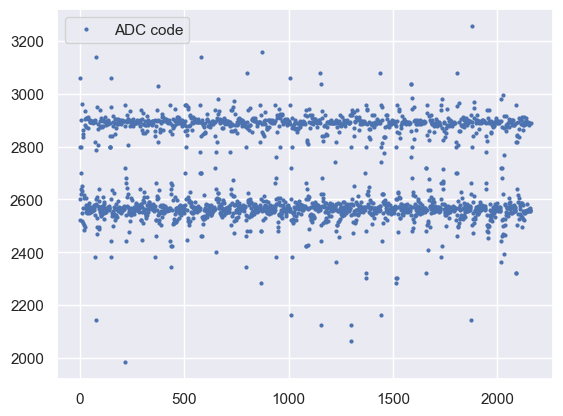

In [122]:
data_subset[["ADC code"]].plot.line(style="o", markersize=2)

# Color by channel name

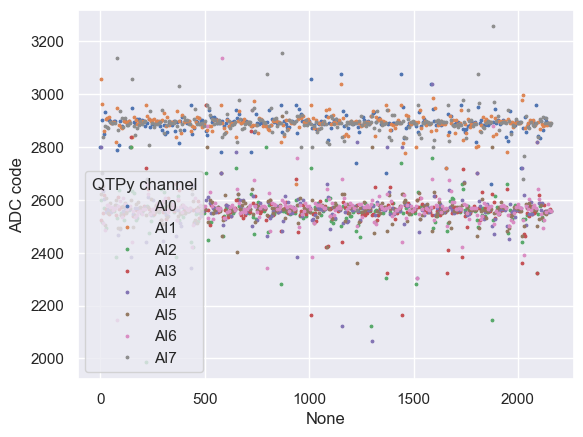

In [123]:
dots = sns.lineplot(data=data_subset, x=data_subset.index, y="ADC code", hue="QTPy channel", linestyle="", marker="o", markersize=2, markeredgecolor=None)

# Plot by samples averaged

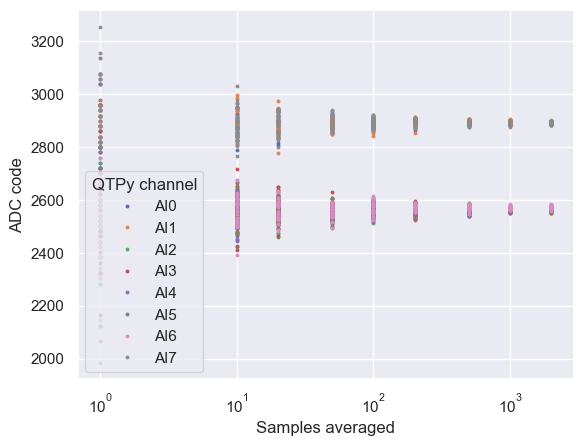

In [124]:
dots2 = sns.lineplot(
    data=data_subset, x="Samples averaged", y="ADC code", hue="QTPy channel",
    linestyle="", marker="o", markersize=2, markeredgecolor=None, estimator=None
)
dots2.set_xscale("log")

# Inspect ADC resolution

## Plot only single-sample data

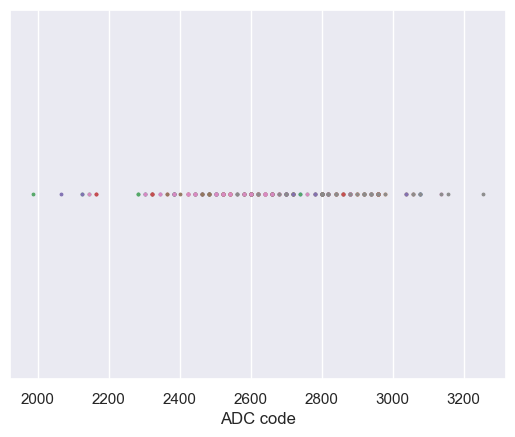

In [125]:
dots_filtered = data_subset[data_subset["Samples averaged"] < 10]
dots3 = sns.lineplot(
    data=dots_filtered, x="ADC code", y="Samples averaged", hue="QTPy channel",
    linestyle="", marker="o", markersize=2, markeredgecolor=None, estimator=None, legend=False
)
dots3.yaxis.set_visible(False)

## How far are ADC codes from each other?

In [126]:
ordered_codes = dots_filtered.sort_values("ADC code")
ordered_codes["code diff"] = ordered_codes["ADC code"].diff()
display(ordered_codes[["ADC code", "code diff"]])

,ADC code,code diff
218,1985.0,NaN
1300,2065.0,80.0
1156,2124.0,59.0
1298,2124.0,0.0
1874,2144.0,20.0
...,...,...
799,3078.0,0.0
79,3137.0,59.0
582,3137.0,0.0
871,3157.0,20.0


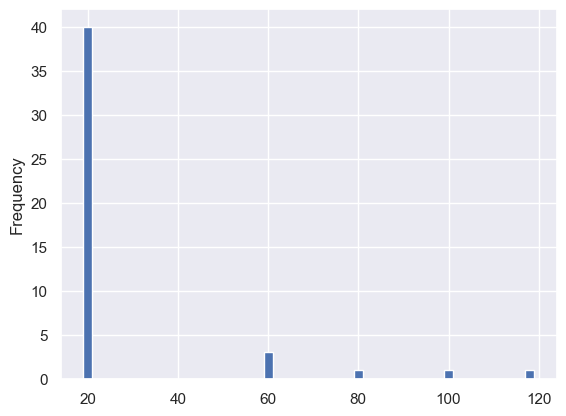

In [127]:

code_filter = (ordered_codes["code diff"] > 0) & (ordered_codes["code diff"] < 200)
code_diff_hists = ordered_codes[code_filter]["code diff"].dropna().plot.hist(bins=50)

### Overlap count

In [128]:
same_code_difference = 0
overlap_count = ordered_codes["code diff"].value_counts()[same_code_difference]
display_markdown(f"## **{overlap_count}** samples have **same** ADC code")

## **193** samples have **same** ADC code

## Measured ADC resolution is 1 mV

In [129]:
ideal_scale_string = f"20 LSB == `{readable_format(volts_per_LSB * 20)}V` _(ideal)_"
display_markdown(f"## {ideal_scale_string}")

## 20 LSB == `1.00708 mV` _(ideal)_

# Plot each channel in its own graph

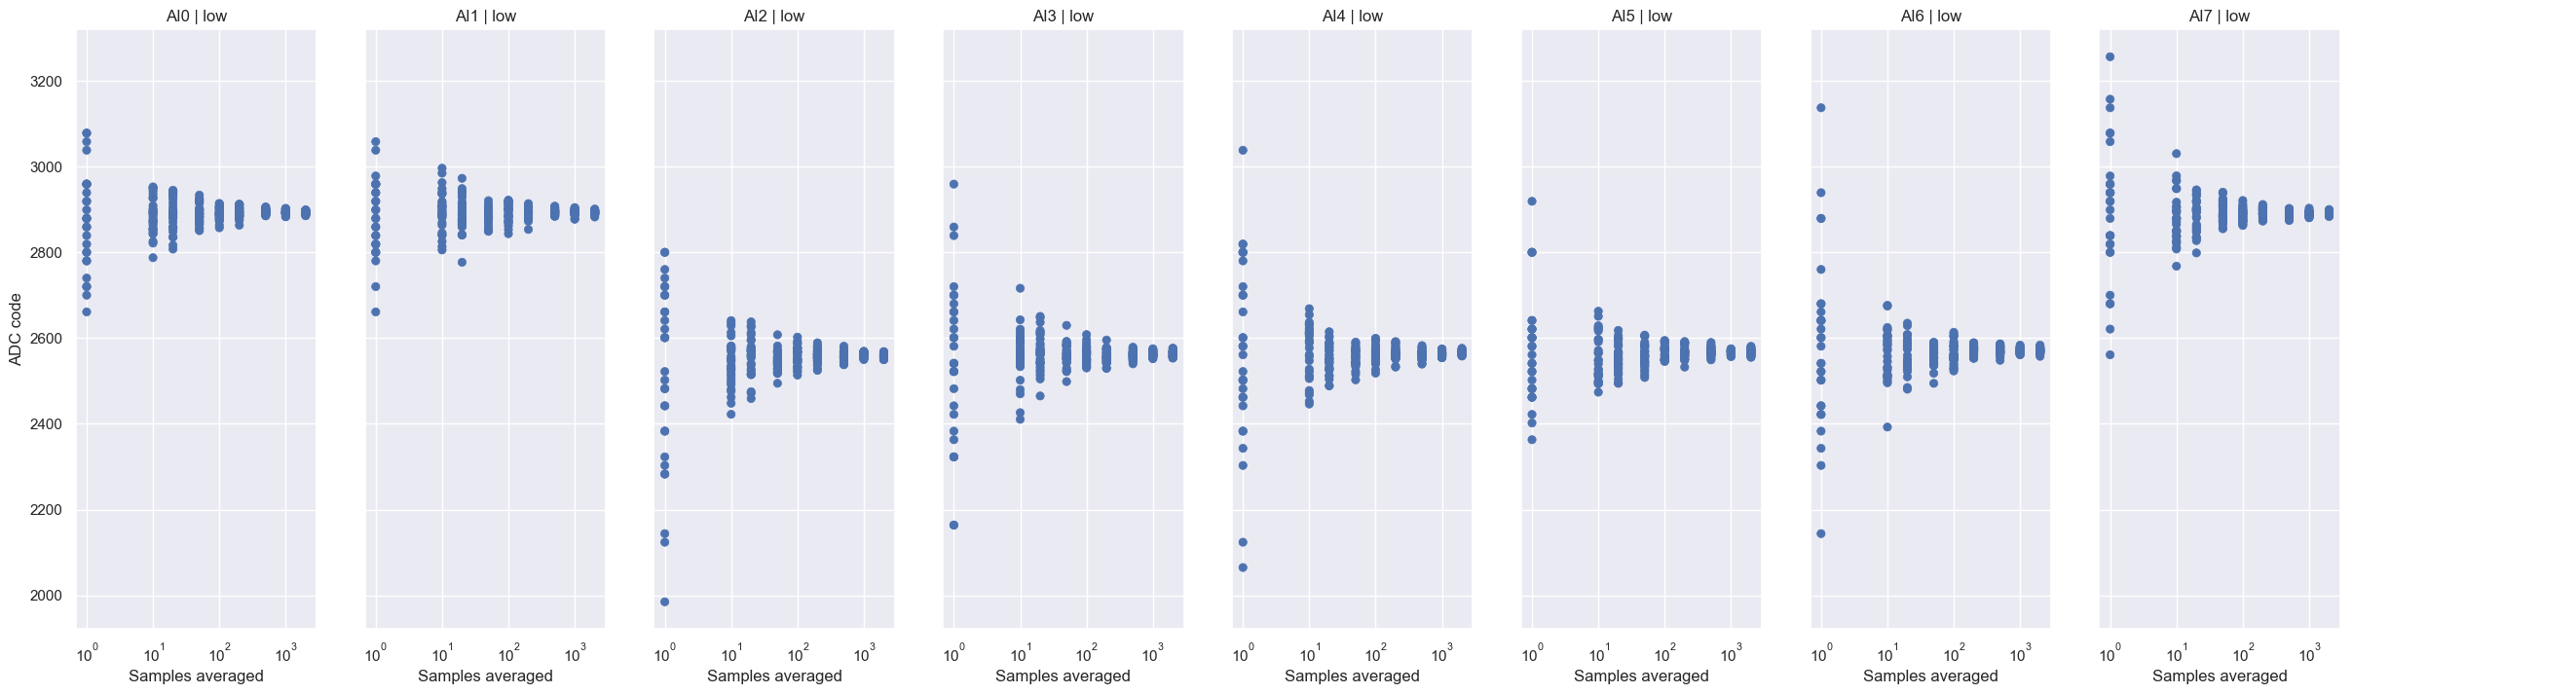

In [130]:
figure = plt.figure(figsize=(30, 8))

plot = (
    so.Plot(
        data_subset,
        x="Samples averaged",
        y="ADC code",
        color="QTPy identifier",
    )
    .facet(row="Reference voltage", col="QTPy channel")
    .share(x=True, y=True)
    .add(so.Dot(), so.Dodge())
    .scale(x="log")
    .on(figure)
)

plot.show()

# Does the QTPy ADC influence the measurement?

In [131]:
group1_channels = data_subset["QTPy channel"].isin(["AI2", "AI3", "AI4", "AI5", "AI6"])
group1_frame = data_subset[group1_channels]

group2_channels = data_subset["QTPy channel"].isin(["AI0", "AI1", "AI7"])
group2_frame = data_subset[group2_channels]

display(group1_frame.head())
display(group2_frame.head())

,QTPy channel,Samples averaged,ADC code,QTPy identifier,Reference voltage,ADC instance
2,AI2,1,2601.0,24ec4a1dc2b8,low,ADC1
3,AI3,1,2522.0,24ec4a1dc2b8,low,ADC1
4,AI4,1,2800.0,24ec4a1dc2b8,low,ADC1
5,AI5,1,2621.0,24ec4a1dc2b8,low,ADC1
6,AI6,1,2641.0,24ec4a1dc2b8,low,ADC1


,QTPy channel,Samples averaged,ADC code,QTPy identifier,Reference voltage,ADC instance
0,AI0,1,2800.0,24ec4a1dc2b8,low,ADC2
1,AI1,1,3058.0,24ec4a1dc2b8,low,ADC2
7,AI7,1,2700.0,24ec4a1dc2b8,low,ADC2
8,AI0,10,2901.0,24ec4a1dc2b8,low,ADC2
9,AI1,10,2962.6,24ec4a1dc2b8,low,ADC2


## Plot each ADC instance on its own graph

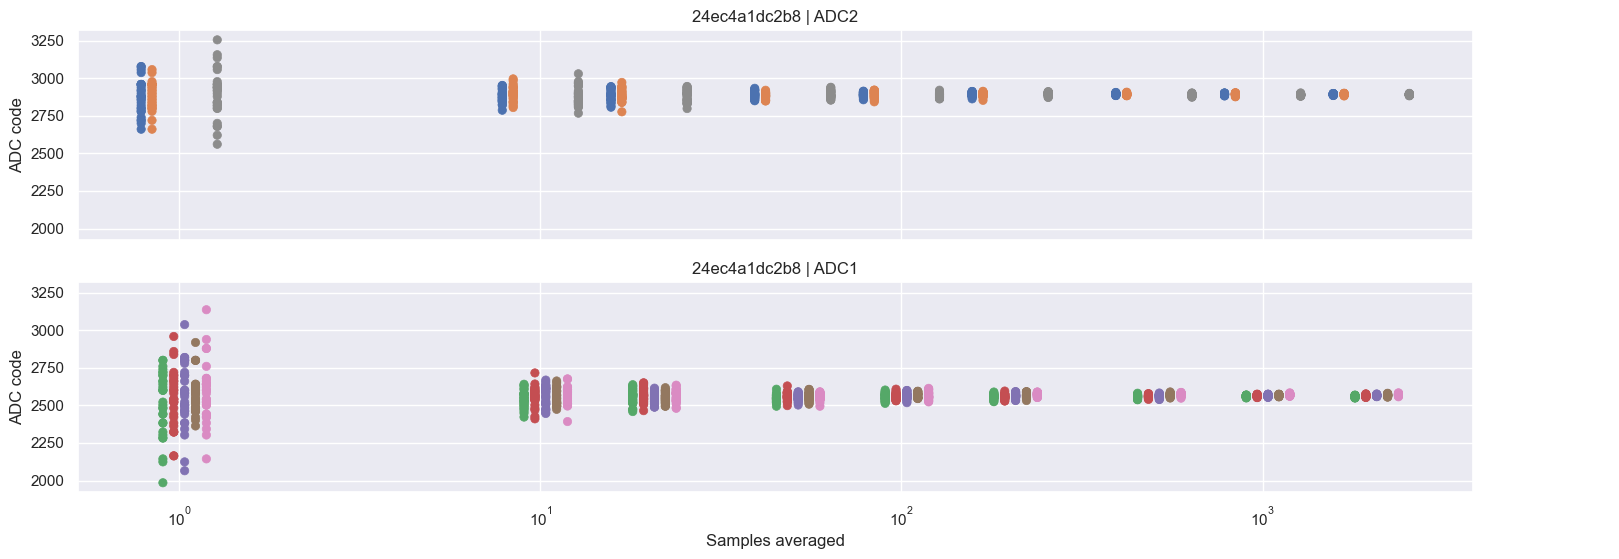

In [132]:
figure2 = plt.figure(figsize=(18,6))

plot2 = (
    so.Plot(
        data_subset,
        x="Samples averaged",
        y="ADC code",
        color="QTPy channel",
    )
    .facet(row="ADC instance", col="QTPy identifier")
    .add(so.Dot(), so.Dodge())
    .scale(x="log")
    .on(figure2)
)

plot2.show()

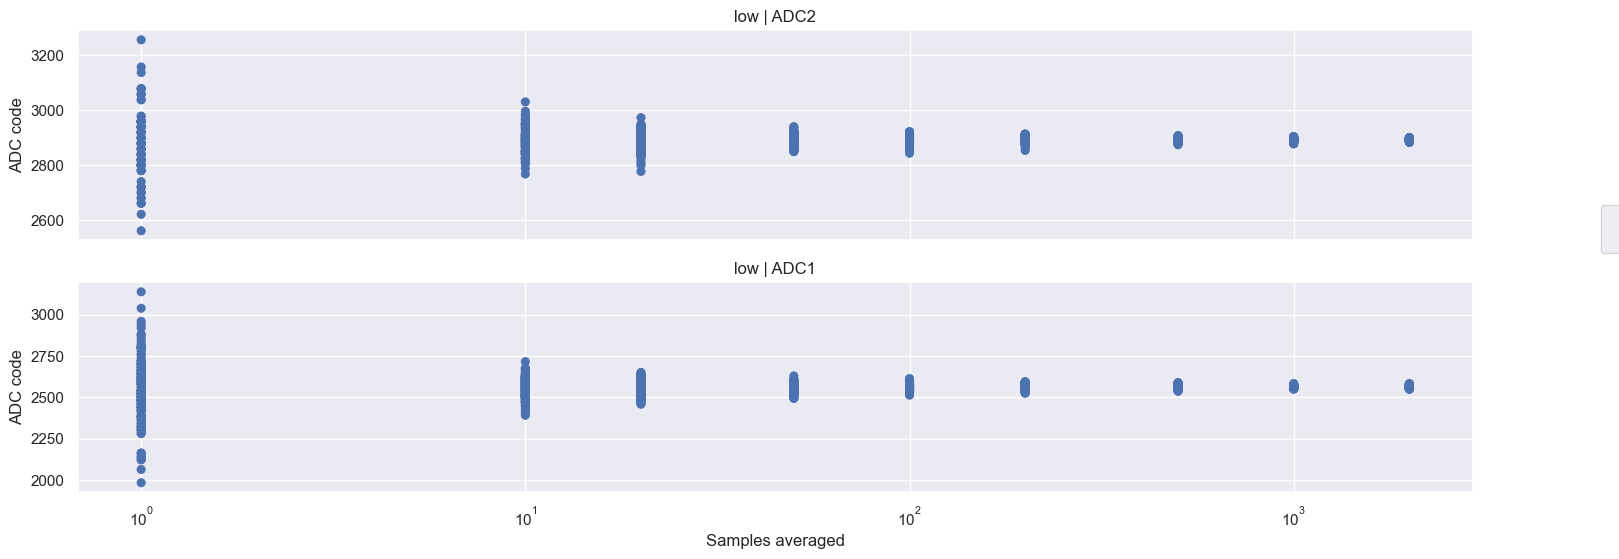

In [133]:
f = plt.figure(figsize=(18,6))

p = (
    so.Plot(
        data_subset,
        x="Samples averaged",
        y="ADC code",
        color="QTPy identifier",
    )
    .facet(row="ADC instance", col="Reference voltage")
    .share(x=True, y=False)
    .add(so.Dot(), so.Dodge())
    .scale(x="log")
    .on(f)
)

p.show()

## Plot statistics about each ADC instance

In [134]:
display_markdown(f"### {oneLSB_scale_string}")
display_markdown(f"### {ideal_scale_string}")

### 1 LSB == `50.354 µV` _(ideal)_

### 20 LSB == `1.00708 mV` _(ideal)_

In [135]:
by_qtpy_adc_vref = data_subset.groupby(["QTPy identifier", "ADC instance", "Reference voltage"])
display(by_qtpy_adc_vref.size())

QTPy identifier  ADC instance  Reference voltage
24ec4a1dc2b8     ADC1          low                  1350
                 ADC2          low                   810
dtype: int64

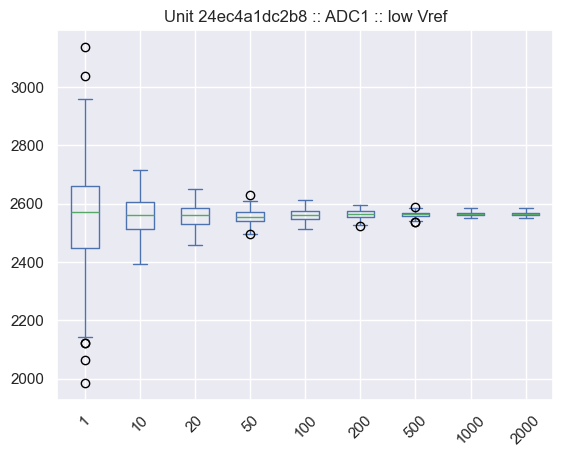

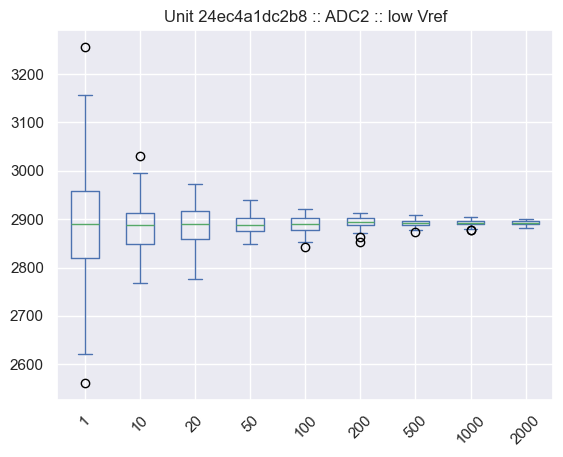

In [136]:
for name, subframe in by_qtpy_adc_vref:
    title = f"Unit {name[0]} :: {name[1]} :: {name[2]} Vref"
    boxplot = subframe.plot.box(by="Samples averaged", column="ADC code", rot=45)
    for axis in boxplot:
        axis.set_title(title)

# Evaluate how averaging impacts accuracy

## Plot the standard deviation of the data for each ADC instance

In [137]:
std_frames = []
for name, subframe in by_qtpy_adc_vref:
    title = f"Unit {name[0]} :: {name[1]} :: {name[2]} Vref"
    std_by_averages = subframe.groupby("Samples averaged")["ADC code"].std()
    qtpy_adc_vref_std = pd.DataFrame({
        "QTPy identifier": name[0],
        "ADC instance": name[1],
        "Reference voltage": name[2],
        "std": std_by_averages,
    })
    std_frames.append(qtpy_adc_vref_std)

all_std_frames = pd.concat(std_frames)
display(all_std_frames)

,QTPy identifier,ADC instance,Reference voltage,std
Samples averaged,,,,
1,24ec4a1dc2b8,ADC1,low,190.527261
10,24ec4a1dc2b8,ADC1,low,58.883057
20,24ec4a1dc2b8,ADC1,low,39.060396
50,24ec4a1dc2b8,ADC1,low,23.865815
100,24ec4a1dc2b8,ADC1,low,20.433624
200,24ec4a1dc2b8,ADC1,low,14.570157
500,24ec4a1dc2b8,ADC1,low,10.565003
1000,24ec4a1dc2b8,ADC1,low,6.619608
2000,24ec4a1dc2b8,ADC1,low,6.883711


In [138]:
std_bar_groups = all_std_frames.groupby(["QTPy identifier", "ADC instance", "Reference voltage"])
display(std_bar_groups.size())

QTPy identifier  ADC instance  Reference voltage
24ec4a1dc2b8     ADC1          low                  9
                 ADC2          low                  9
dtype: int64

In [139]:
std_bars_by_qtpy_acd_vref = pd.DataFrame()
for name, subframe in std_bar_groups:
    column_name = f"Unit {name[0]} :: {name[1]} :: {name[2]} Vref"
    std_bars_by_qtpy_acd_vref[column_name] = subframe["std"]

display(std_bars_by_qtpy_acd_vref)

,Unit 24ec4a1dc2b8 :: ADC1 :: low Vref,Unit 24ec4a1dc2b8 :: ADC2 :: low Vref
Samples averaged,,
1,190.527261,122.619921
10,58.883057,49.555662
20,39.060396,38.807097
50,23.865815,21.302207
100,20.433624,16.855198
200,14.570157,11.421747
500,10.565003,6.721425
1000,6.619608,5.588433
2000,6.883711,3.935630


,Unit 24ec4a1dc2b8 :: ADC1 :: low Vref % change,Unit 24ec4a1dc2b8 :: ADC2 :: low Vref % change
Samples averaged,,
1,NaN,NaN
10,-69.094681,-59.585962
20,-33.664456,-21.689882
50,-38.900222,-45.107445
100,-14.381203,-20.875814
200,-28.695191,-32.236058
500,-27.488747,-41.152387
1000,-37.344003,-16.856426
2000,3.989711,-29.575430


Text(0, 0.5, '% improvement in std')

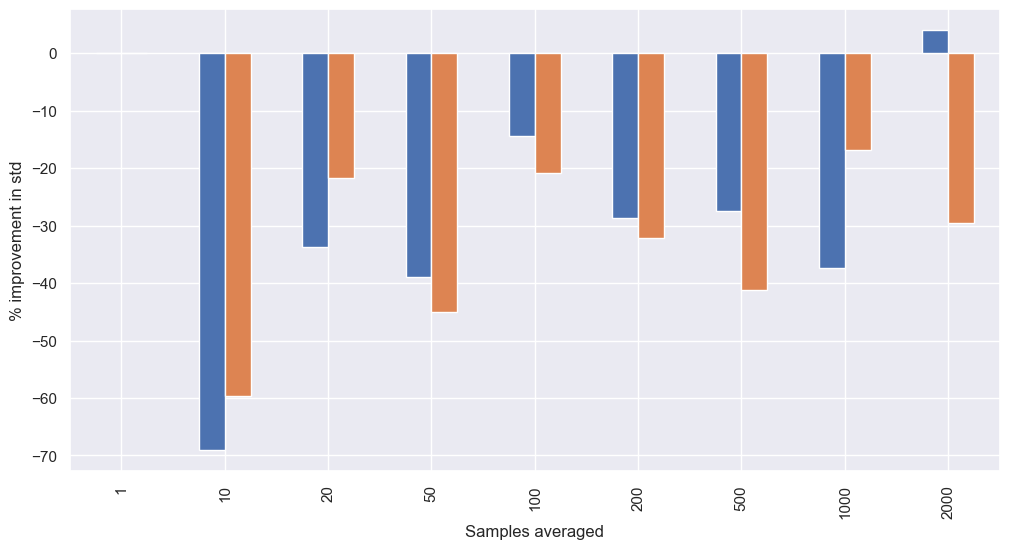

In [140]:
explore_diff = std_bars_by_qtpy_acd_vref.pct_change() * 100
explore_diff = explore_diff.rename(columns={name: f"{name} % change" for name in std_bars_by_qtpy_acd_vref.columns})
display(explore_diff)
diff_bars = explore_diff.plot.bar(figsize=(12, 6), legend=False)
diff_bars.set_ylabel("% improvement in std")

In [141]:
explore_diff[explore_diff <= -20].count(axis="columns")

Samples averaged
1       0
10      2
20      2
50      2
100     1
200     2
500     2
1000    1
2000    1
dtype: int64

(0.0, 60.0)

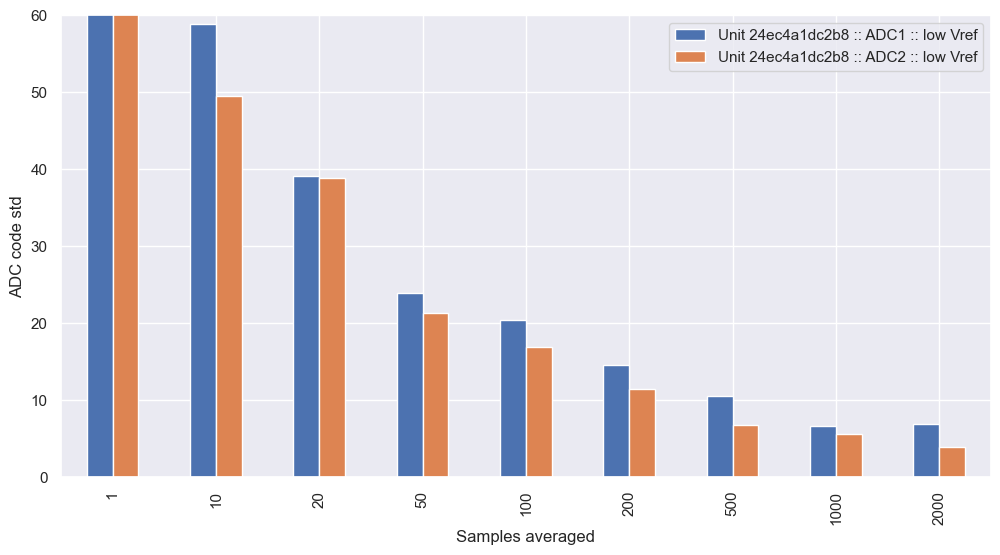

In [142]:
std_bars = std_bars_by_qtpy_acd_vref.plot.bar(figsize=(12,6))
std_bars.set_ylabel("ADC code std")
std_bars.set_ylim(top=60)

## Plot again but scale to volts

Text(0, 0.5, 'ADC std (mV)')

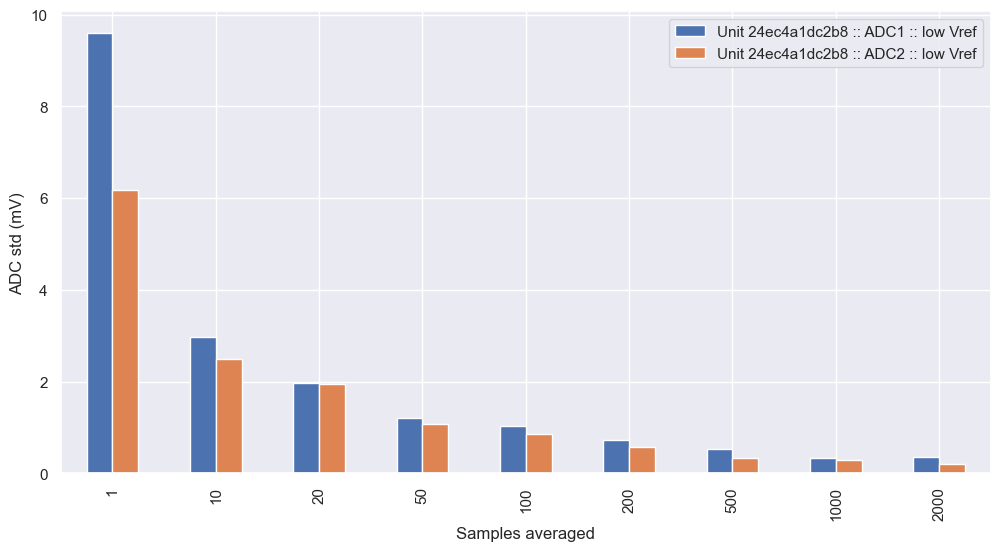

In [143]:
scaled_qtpy_adc_std = std_bars_by_qtpy_acd_vref * volts_per_LSB * 1000
scaled_std_bars = scaled_qtpy_adc_std.plot.bar(figsize=(12,6))
scaled_std_bars.set_ylabel("ADC std (mV)")
#scaled_std_bars.set_ylim(top=4)

## Choose a cut-in uncertainty of accuracy and plot statistics

In [144]:
mV_cutin = 2.0
filtered = scaled_qtpy_adc_std[scaled_qtpy_adc_std < mV_cutin]
display(filtered)

,Unit 24ec4a1dc2b8 :: ADC1 :: low Vref,Unit 24ec4a1dc2b8 :: ADC2 :: low Vref
Samples averaged,,
1,NaN,NaN
10,NaN,NaN
20,1.966847,1.954093
50,1.201739,1.072651
100,1.028915,0.848727
200,0.733666,0.575131
500,0.531990,0.338451
1000,0.333324,0.281400
2000,0.346622,0.198175


In [145]:
count_required_to_meet_minimum_uncertainty = len(filtered.columns)
display_markdown(f"### Count required to meet minimum uncertainty == `{count_required_to_meet_minimum_uncertainty}`")

### Count required to meet minimum uncertainty == `2`

In [146]:
meets_minimum_undertainty = filtered.count(axis="columns") == count_required_to_meet_minimum_uncertainty
display(meets_minimum_undertainty)

Samples averaged
1       False
10      False
20       True
50       True
100      True
200      True
500      True
1000     True
2000     True
dtype: bool

In [147]:
lowest_average_to_meet_minimum_uncertainty = meets_minimum_undertainty.loc[meets_minimum_undertainty == True].index[0]
display_markdown(f"## Lowest average count to meet **{mV_cutin} mV** cut-in\n`{lowest_average_to_meet_minimum_uncertainty}` samples averaged")

## Lowest average count to meet **2.0 mV** cut-in
`20` samples averaged

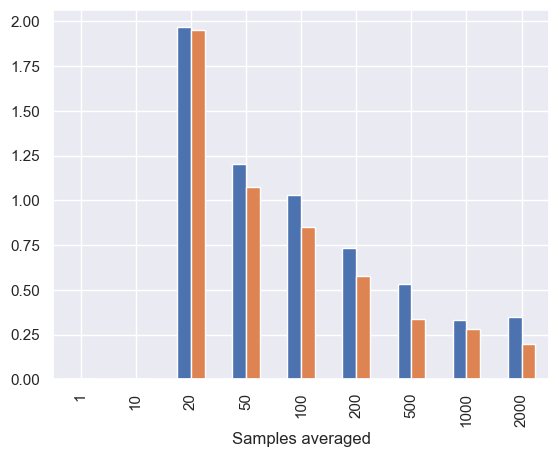

In [148]:
bars_qtpy2 = filtered.plot.bar(legend=False)

## Choose a cut-in average count and plot statistics

In [149]:
avg_count_cutin = 50
all_filtered = data_subset[(data_subset["Samples averaged"] > avg_count_cutin)]
display(all_filtered)

,QTPy channel,Samples averaged,ADC code,QTPy identifier,Reference voltage,ADC instance
32,AI0,100,2907.71,24ec4a1dc2b8,low,ADC2
33,AI1,100,2908.07,24ec4a1dc2b8,low,ADC2
34,AI2,100,2558.08,24ec4a1dc2b8,low,ADC1
35,AI3,100,2564.64,24ec4a1dc2b8,low,ADC1
36,AI4,100,2566.67,24ec4a1dc2b8,low,ADC1
...,...,...,...,...,...,...
2155,AI3,2000,2566.17,24ec4a1dc2b8,low,ADC1
2156,AI4,2000,2558.08,24ec4a1dc2b8,low,ADC1
2157,AI5,2000,2559.67,24ec4a1dc2b8,low,ADC1
2158,AI6,2000,2557.43,24ec4a1dc2b8,low,ADC1


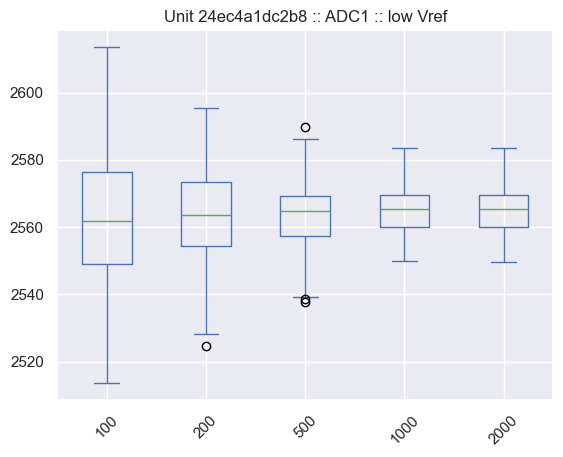

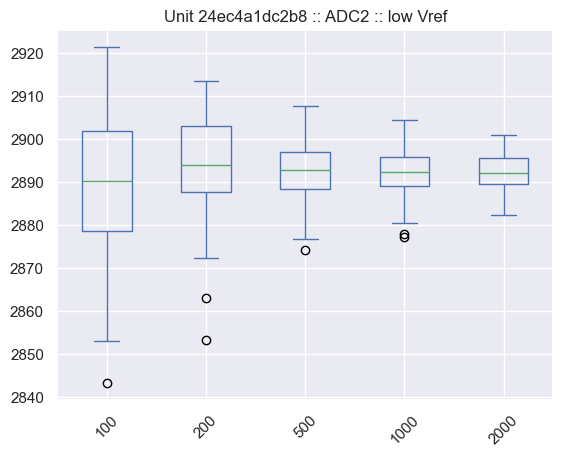

In [150]:
for name, subframe in all_filtered.groupby(["QTPy identifier", "ADC instance", "Reference voltage"]):
    title = f"Unit {name[0]} :: {name[1]} :: {name[2]} Vref"
    boxplot = subframe.plot.box(by="Samples averaged", column="ADC code", rot=45)
    for axis in boxplot:
        axis.set_title(title)